<a href="https://colab.research.google.com/github/ntomben97/NYC-Yellow-Taxi-Big-Data-Project/blob/main/Exploratory_Data_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Loading Data for Analysis

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

!pip install pyspark -q

Mounted at /content/drive


In [ ]:
from pyspark.sql import SparkSession
from pathlib import Path

spark = SparkSession.builder \
    .appName("NYC Taxi Analysis") \
    .getOrCreate()

In [ ]:
import os
import pandas as pd
from pyspark.sql import functions as F

FIGURE_DIR = "/content/drive/MyDrive/MIT805/Group Project/Figures"
os.makedirs(FIGURE_DIR, exist_ok=True)

In [ ]:
df = spark.read.parquet(
    "/content/drive/MyDrive/MIT805/Group Project/ProcessedData/CleanedData"
)

df.show(5)

+--------+--------------------+---------------------+---------------+-------------+----------+------------------+------------+------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+--------------------+-----------+------------------+
|vendorid|tpep_pickup_datetime|tpep_dropoff_datetime|passenger_count|trip_distance|ratecodeid|store_and_fwd_flag|pulocationid|dolocationid|payment_type|fare_amount|extra|mta_tax|tip_amount|tolls_amount|improvement_surcharge|total_amount|congestion_surcharge|airport_fee|cbd_congestion_fee|
+--------+--------------------+---------------------+---------------+-------------+----------+------------------+------------+------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+--------------------+-----------+------------------+
|       1| 2016-01-01 00:12:22|  2016-01-01 00:29:14|            1.0|          3.2|         1|                 N|          48|    

Analysis of trips over time

In [ ]:
trips_year = (
    df
    .withColumn("year", F.year("tpep_pickup_datetime"))
    .groupBy("year")
    .count()
    .orderBy("year")
)

trips_year.show(5)

+----+---------+
|year|    count|
+----+---------+
|2014|152335463|
|2015|133596838|
|2016|262263610|
|2017|227000772|
|2018|205741048|
+----+---------+
only showing top 5 rows


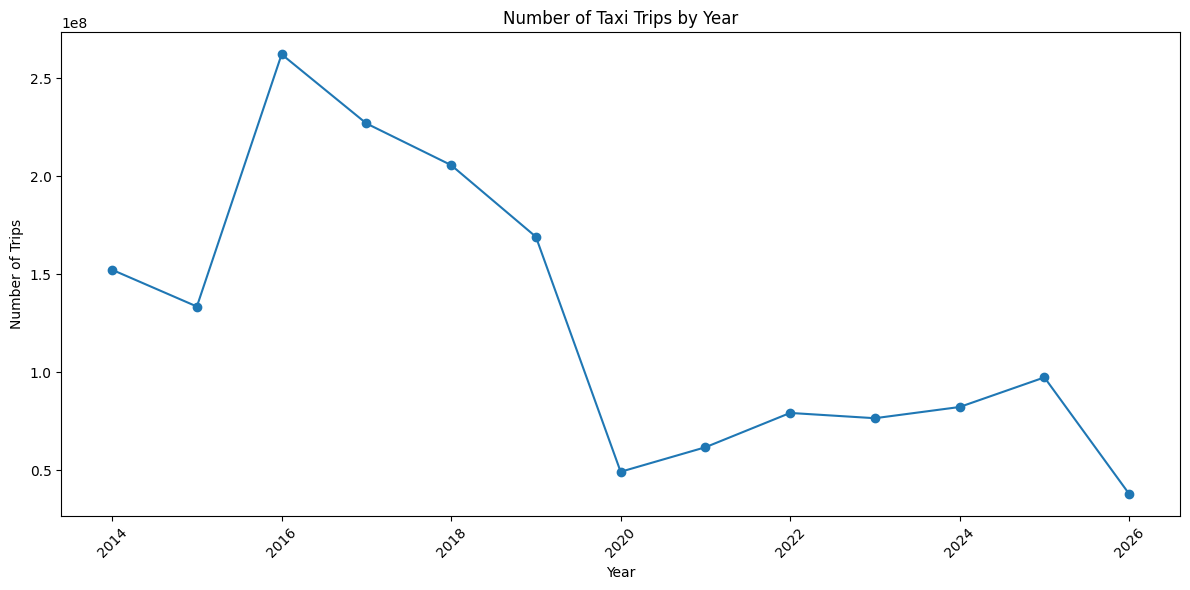

In [ ]:
import matplotlib.pyplot as plt

trips_year_pd = trips_year.toPandas()
plt.figure(figsize=(12, 6))

plt.plot(
    trips_year_pd["year"],
    trips_year_pd["count"],
    marker="o"
)

plt.xlabel("Year")
plt.ylabel("Number of Trips")
plt.title("Number of Taxi Trips by Year")
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig(
    os.path.join(FIGURE_DIR, "no_taxi_trips_by_year.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
from pyspark.sql import functions as F

trips_month_year = (
    df
    .withColumn("year", F.year("tpep_pickup_datetime"))
    .withColumn("month", F.month("tpep_pickup_datetime"))
    .groupBy("year", "month")
    .count()
    .orderBy("year", "month")
)

trips_month_year_pd = trips_month_year.toPandas()

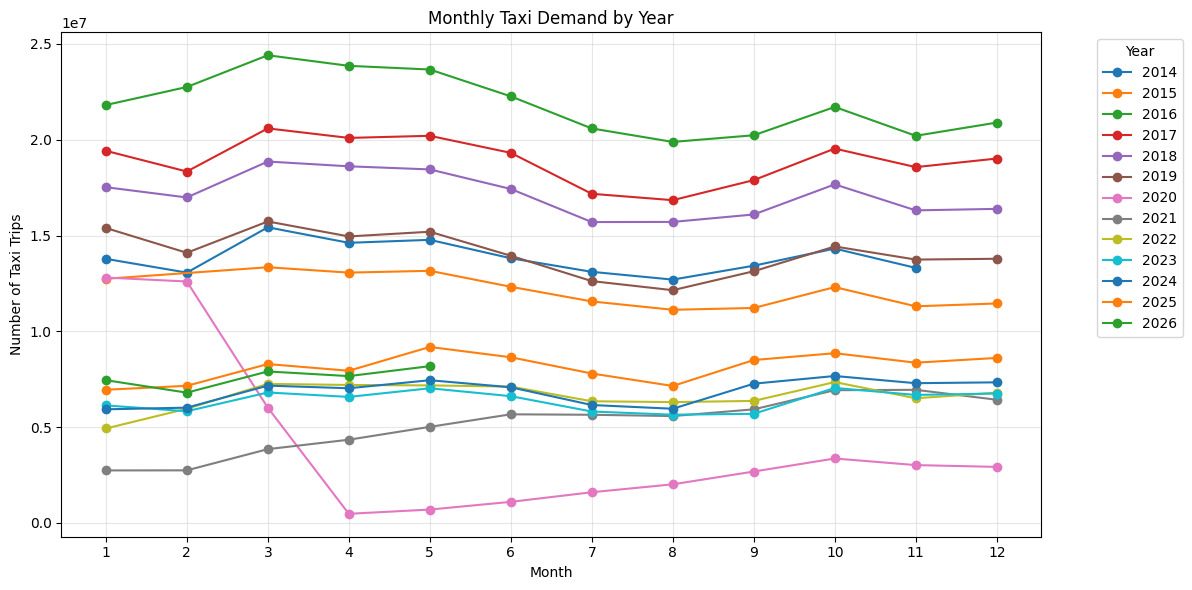

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

for year in sorted(trips_month_year_pd["year"].unique()):
    year_data = trips_month_year_pd[
        trips_month_year_pd["year"] == year
    ]

    plt.plot(
        year_data["month"],
        year_data["count"],
        marker="o",
        label=str(year)
    )

plt.xlabel("Month")
plt.ylabel("Number of Taxi Trips")
plt.title("Monthly Taxi Demand by Year")
plt.xticks(range(1, 13))
plt.legend(title="Year", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(
    os.path.join(FIGURE_DIR, "monthly_taxi_demand_by_year.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [ ]:
from pyspark.sql import functions as F

daily_weekday_demand = (
    df
    .withColumn(
        "day_of_week",
        F.date_format("tpep_pickup_datetime", "EEEE")
    )
    .groupBy("day_of_week")
    .agg(
        F.count("*").alias("trip_count")
    )
)

# Put the days in the correct Monday–Sunday order
day_order = (
    F.when(F.col("day_of_week") == "Monday", 1)
     .when(F.col("day_of_week") == "Tuesday", 2)
     .when(F.col("day_of_week") == "Wednesday", 3)
     .when(F.col("day_of_week") == "Thursday", 4)
     .when(F.col("day_of_week") == "Friday", 5)
     .when(F.col("day_of_week") == "Saturday", 6)
     .when(F.col("day_of_week") == "Sunday", 7)
)

daily_weekday_demand = (
    daily_weekday_demand
    .withColumn("day_order", day_order)
    .orderBy("day_order")
)

daily_weekday_demand.show()
weekday_demand_pd = daily_weekday_demand.toPandas()

+-----------+----------+---------+
|day_of_week|trip_count|day_order|
+-----------+----------+---------+
|     Monday| 209193592|        1|
|    Tuesday| 231021528|        2|
|  Wednesday| 241568753|        3|
|   Thursday| 248847088|        4|
|     Friday| 249661127|        5|
|   Saturday| 244082504|        6|
|     Sunday| 210555983|        7|
+-----------+----------+---------+



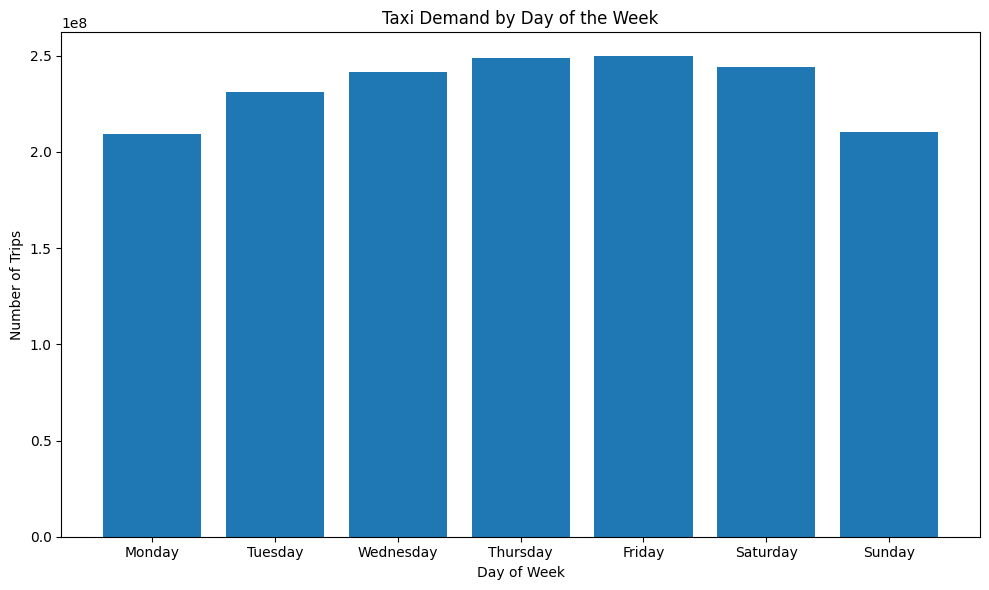

In [ ]:
import matplotlib.pyplot as plt
import os

plt.figure(figsize=(10, 6))

plt.bar(
    weekday_demand_pd["day_of_week"],
    weekday_demand_pd["trip_count"]
)

plt.xlabel("Day of Week")
plt.ylabel("Number of Trips")
plt.title("Taxi Demand by Day of the Week")

plt.tight_layout()

plt.savefig(
    os.path.join(FIGURE_DIR, "taxi_demand_by_day_of_week.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
from pyspark.sql import functions as F

trips_hour_month = (
    df
    .withColumn("month", F.month("tpep_pickup_datetime"))
    .withColumn("hour", F.hour("tpep_pickup_datetime"))
    .groupBy("month", "hour")
    .count()
    .orderBy("month", "hour")
)

trips_hour_month_pd = trips_hour_month.toPandas()

In [ ]:
heatmap_data = trips_hour_month_pd.pivot(
    index="hour",
    columns="month",
    values="count"
)

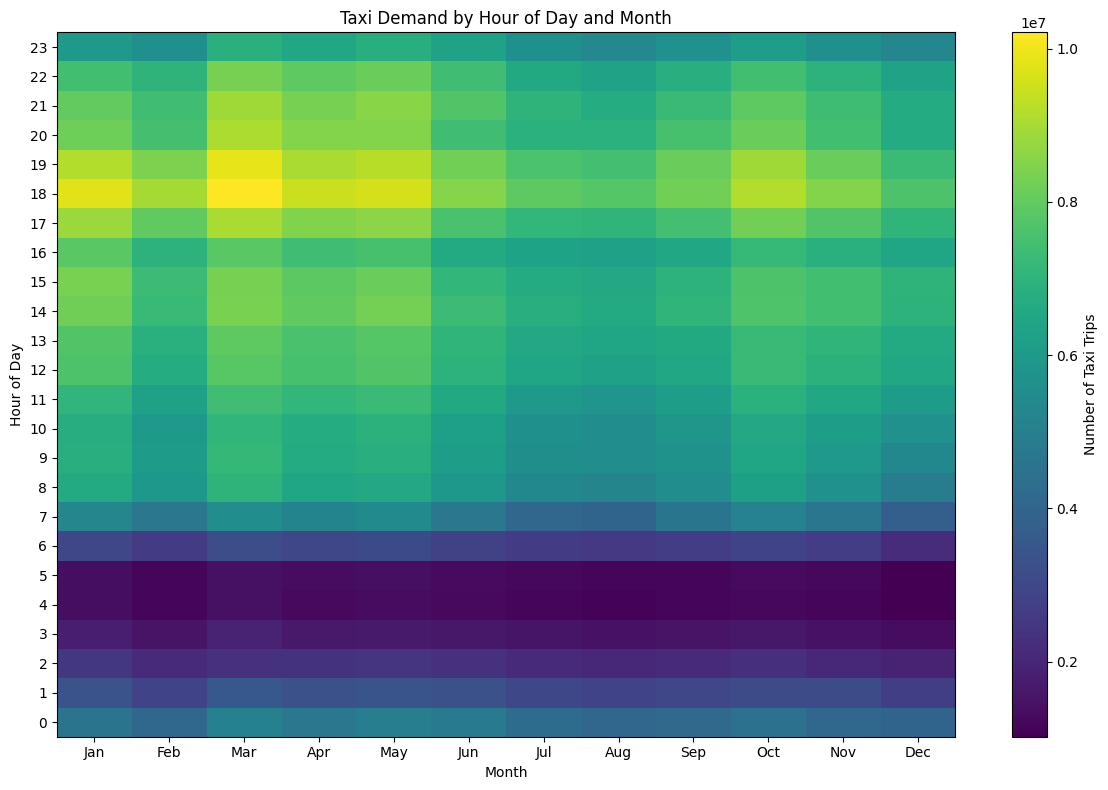

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))

plt.imshow(
    heatmap_data,
    aspect="auto",
    origin="lower"
)

plt.colorbar(label="Number of Taxi Trips")

plt.xlabel("Month")
plt.ylabel("Hour of Day")
plt.title("Taxi Demand by Hour of Day and Month")

plt.xticks(
    range(12),
    ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
     "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
)

plt.yticks(range(24), range(24))

plt.tight_layout()
plt.savefig(
    os.path.join(FIGURE_DIR, "taxi_demand_by_hour_month.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.show()

Analysis of trips by location

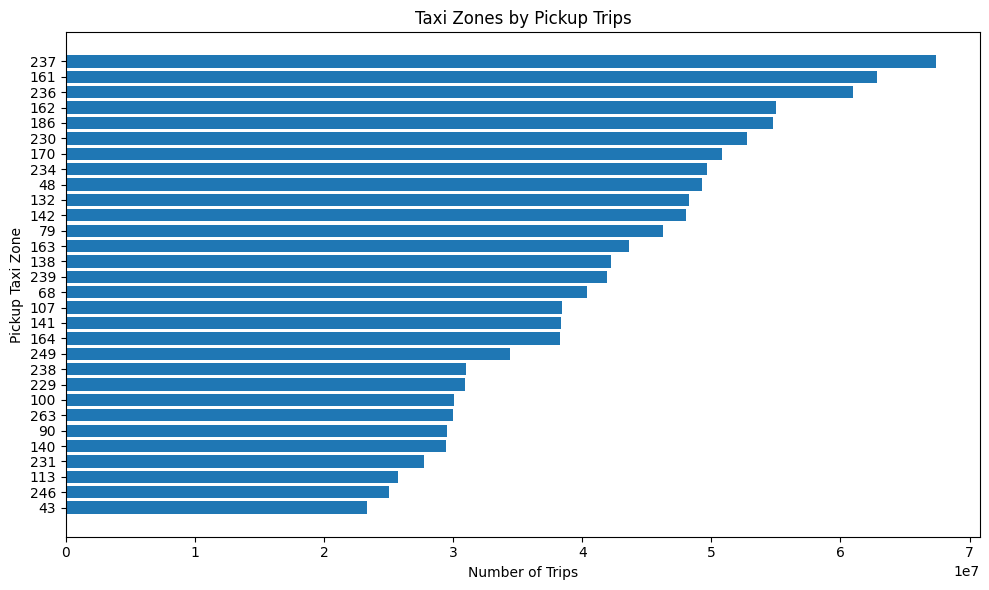

In [ ]:
from pyspark.sql import functions as F
import matplotlib.pyplot as plt
import os

pickup_counts = (
    df.groupBy("PULocationID")
      .count()
      .orderBy(F.desc("count"))
      .limit(30)
)

pickup_pd = pickup_counts.toPandas()

plt.figure(figsize=(10, 6))

plt.barh(
    pickup_pd["PULocationID"].astype(str)[::-1],
    pickup_pd["count"][::-1]
)

plt.title("Taxi Zones by Pickup Trips")
plt.xlabel("Number of Trips")
plt.ylabel("Pickup Taxi Zone")

plt.tight_layout()

plt.savefig(
    os.path.join(FIGURE_DIR, "pickup_zones.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

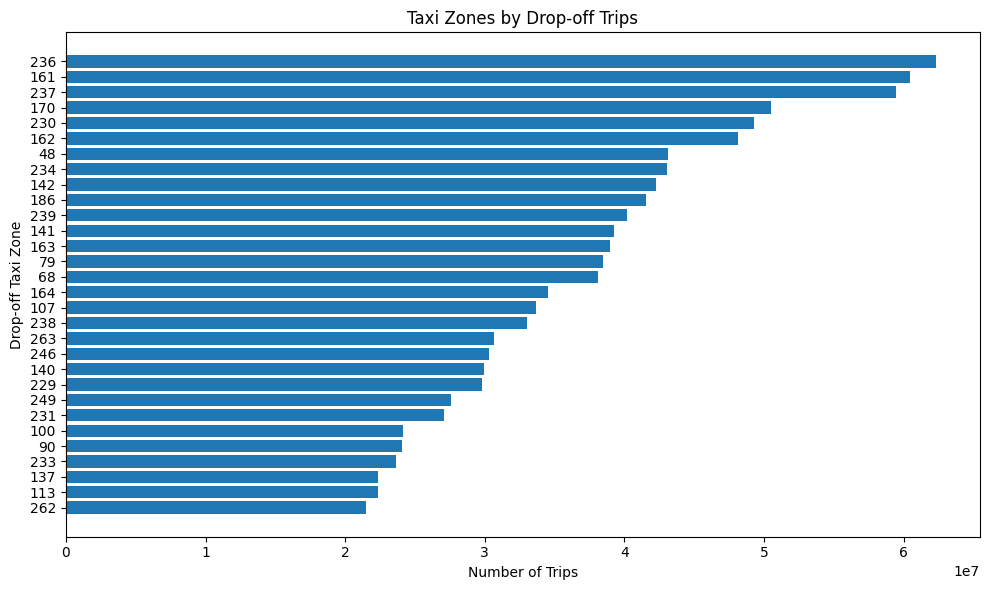

In [ ]:
dropoff_counts = (
    df.groupBy("DOLocationID")
      .count()
      .orderBy(F.desc("count"))
      .limit(30)
)

dropoff_pd = dropoff_counts.toPandas()

plt.figure(figsize=(10, 6))

plt.barh(
    dropoff_pd["DOLocationID"].astype(str)[::-1],
    dropoff_pd["count"][::-1]
)

plt.title("Taxi Zones by Drop-off Trips")
plt.xlabel("Number of Trips")
plt.ylabel("Drop-off Taxi Zone")

plt.tight_layout()

plt.savefig(
    os.path.join(FIGURE_DIR, "dropoff_zones.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
from pyspark.sql import functions as F

pickup = (
    df.groupBy("PULocationID")
      .agg(F.count("*").alias("pickup_trips"))
      .withColumnRenamed("PULocationID", "LocationID")
)

dropoff = (
    df.groupBy("DOLocationID")
      .agg(F.count("*").alias("dropoff_trips"))
      .withColumnRenamed("DOLocationID", "LocationID")
)

zone_demand = (
    pickup.join(dropoff, on="LocationID", how="outer")
          .fillna(0)
          .withColumn(
              "net_demand",
              F.col("pickup_trips") - F.col("dropoff_trips")
          )
)

zone_demand.orderBy(
    F.desc("net_demand")
).show(20)

+----------+------------+-------------+----------+
|LocationID|pickup_trips|dropoff_trips|net_demand|
+----------+------------+-------------+----------+
|       132|    48235656|     15097511|  33138145|
|       138|    42228938|     18663414|  23565524|
|       186|    54785424|     41518861|  13266563|
|       237|    67438598|     59412227|   8026371|
|        79|    46268803|     38474286|   7794517|
|       162|    55021258|     48126307|   6894951|
|       249|    34424322|     27576064|   6848258|
|       234|    49654359|     43026724|   6627635|
|        48|    49238527|     43106495|   6132032|
|       100|    30045224|     24165024|   5880200|
|       142|    48006405|     42285264|   5721141|
|        90|    29522836|     24054695|   5468141|
|       114|    22512633|     17610236|   4902397|
|       107|    38426125|     33695015|   4731110|
|       163|    43593257|     38957340|   4635917|
|       148|    22045202|     17701062|   4344140|
|        43|    23320256|     1

Analysis of taxi finances

In [ ]:
distance_fare_grouped = (
    df
    .filter(
        (F.col("trip_distance") > 0) &
        (F.col("trip_distance") < 100) &
        (F.col("fare_amount") > 0)
    )
    .withColumn(
        "distance_group",
        F.floor(F.col("trip_distance"))
    )
    .groupBy("distance_group")
    .agg(
        F.avg("trip_distance").alias("avg_trip_distance"),
        F.avg("fare_amount").alias("avg_fare_amount"),
        F.count("*").alias("trip_count")
    )
    .orderBy("distance_group")
)
distance_fare_pd = distance_fare_grouped.toPandas()

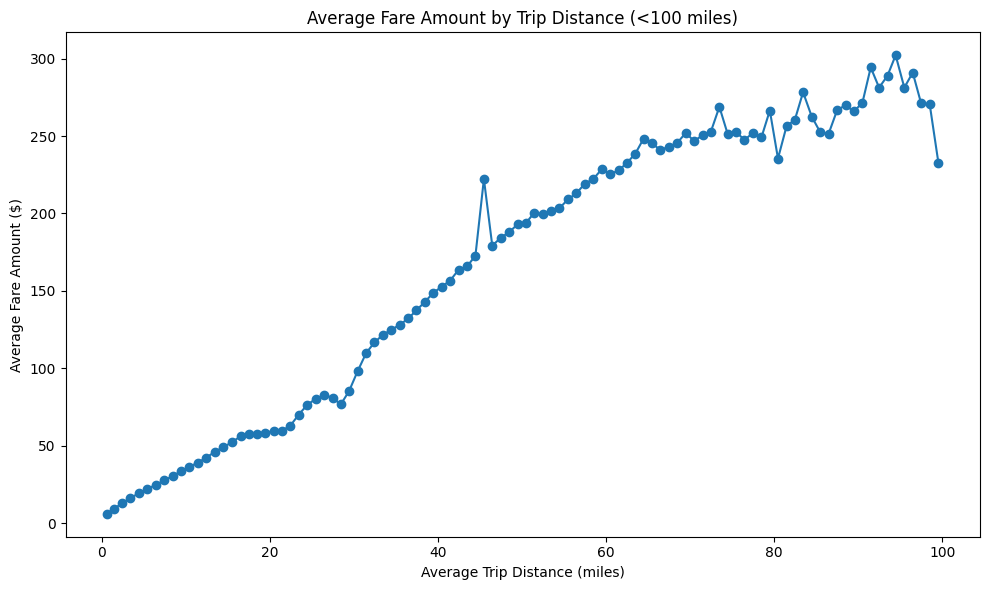

In [ ]:
plt.figure(figsize=(10, 6))

plt.plot(
    distance_fare_pd["avg_trip_distance"],
    distance_fare_pd["avg_fare_amount"],
    marker="o"
)

plt.xlabel("Average Trip Distance (miles)")
plt.ylabel("Average Fare Amount ($)")
plt.title("Average Fare Amount by Trip Distance (<100 miles)")

plt.tight_layout()

plt.savefig(
    os.path.join(FIGURE_DIR, "average_distance_vs_fare_under_100_miles.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
from pyspark.sql import functions as F

distance_tip_grouped = (
    df
    .filter(
        (F.col("payment_type") == 1) &
        (F.col("trip_distance") > 0) &
        (F.col("trip_distance") < 100) &
        (F.col("tip_amount") >= 0)
    )
    .withColumn(
        "distance_group",
        F.floor(F.col("trip_distance"))
    )
    .groupBy("distance_group")
    .agg(
        F.avg("trip_distance").alias("avg_trip_distance"),
        F.avg("tip_amount").alias("avg_tip_amount"),
        F.count("*").alias("trip_count")
    )
    .orderBy("distance_group")
)
distance_tip_pd = distance_tip_grouped.toPandas()

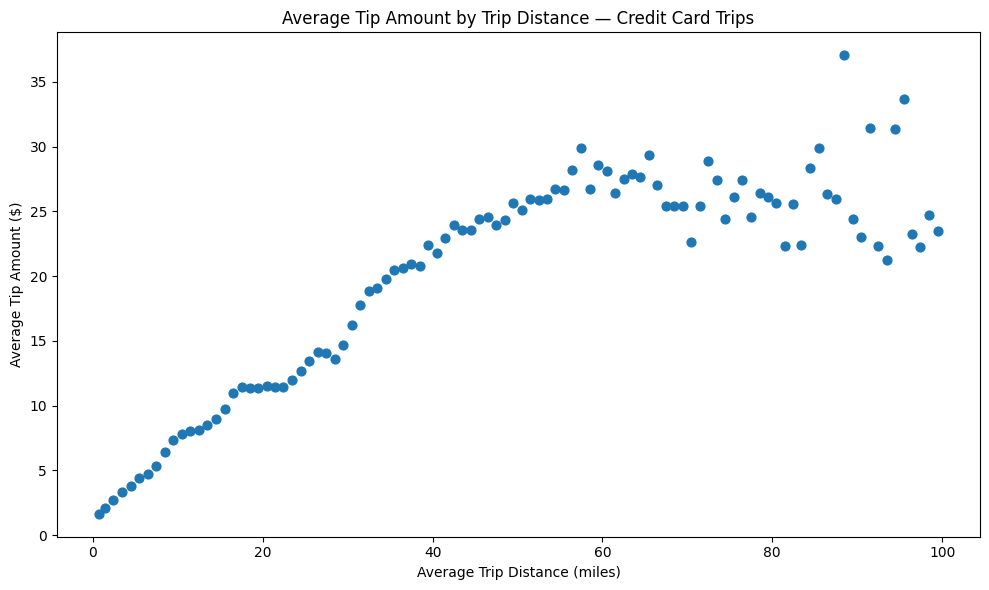

In [ ]:
import matplotlib.pyplot as plt
import os

plt.figure(figsize=(10, 6))

plt.scatter(
    distance_tip_pd["avg_trip_distance"],
    distance_tip_pd["avg_tip_amount"],
    s=40
)

plt.xlabel("Average Trip Distance (miles)")
plt.ylabel("Average Tip Amount ($)")
plt.title("Average Tip Amount by Trip Distance — Credit Card Trips")

plt.tight_layout()

plt.savefig(
    os.path.join(
        FIGURE_DIR,
        "trip_distance_vs_tip_amount_credit_card.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

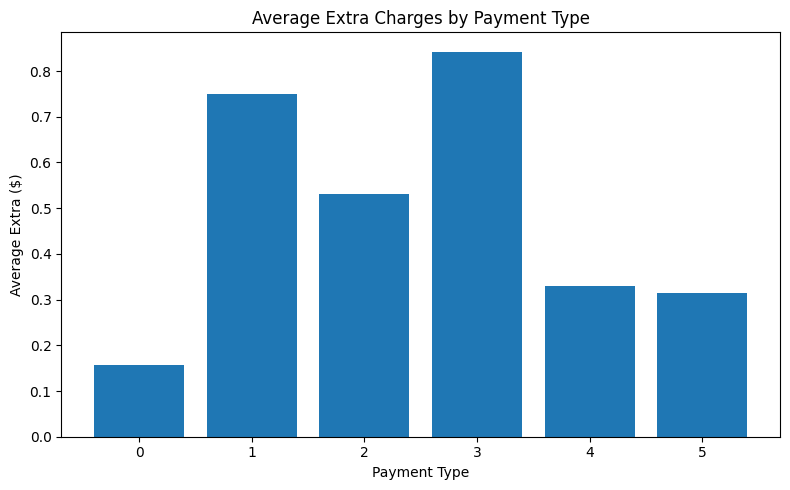

In [ ]:
payment_extra = (
    df
    .groupBy("payment_type")
    .agg(
        F.avg("extra").alias("avg_extra")
    )
    .orderBy("payment_type")
)

payment_extra_pd = payment_extra.toPandas()

plt.figure(figsize=(8, 5))

plt.bar(
    payment_extra_pd["payment_type"].astype(str),
    payment_extra_pd["avg_extra"]
)

plt.xlabel("Payment Type")
plt.ylabel("Average Extra ($)")
plt.title("Average Extra Charges by Payment Type")

plt.tight_layout()

plt.savefig(
    os.path.join(FIGURE_DIR, "payment_type_vs_average_extra.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()


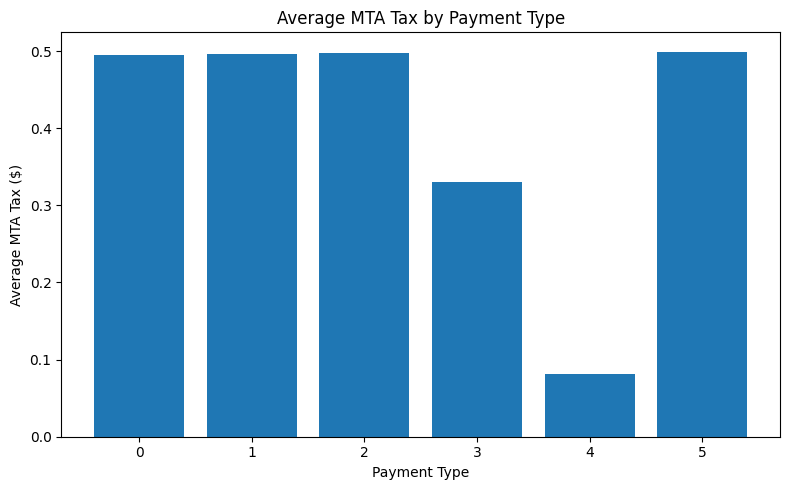

In [ ]:
payment_tax = (
    df
    .groupBy("payment_type")
    .agg(
        F.avg("mta_tax").alias("avg_mta_tax")
    )
    .orderBy("payment_type")
)

payment_tax_pd = payment_tax.toPandas()

plt.figure(figsize=(8, 5))

plt.bar(
    payment_tax_pd["payment_type"].astype(str),
    payment_tax_pd["avg_mta_tax"]
)

plt.xlabel("Payment Type")
plt.ylabel("Average MTA Tax ($)")
plt.title("Average MTA Tax by Payment Type")

plt.tight_layout()

plt.savefig(
    os.path.join(FIGURE_DIR, "payment_type_vs_average_mta_tax.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
rate_fare = (
    df
    .filter(F.col("fare_amount") > 0)
    .groupBy("ratecodeid")
    .agg(
        F.avg("fare_amount").alias("avg_fare_amount"),
        F.count("*").alias("trip_count")
    )
    .orderBy("ratecodeid")
)

rate_fare_pd = rate_fare.toPandas()

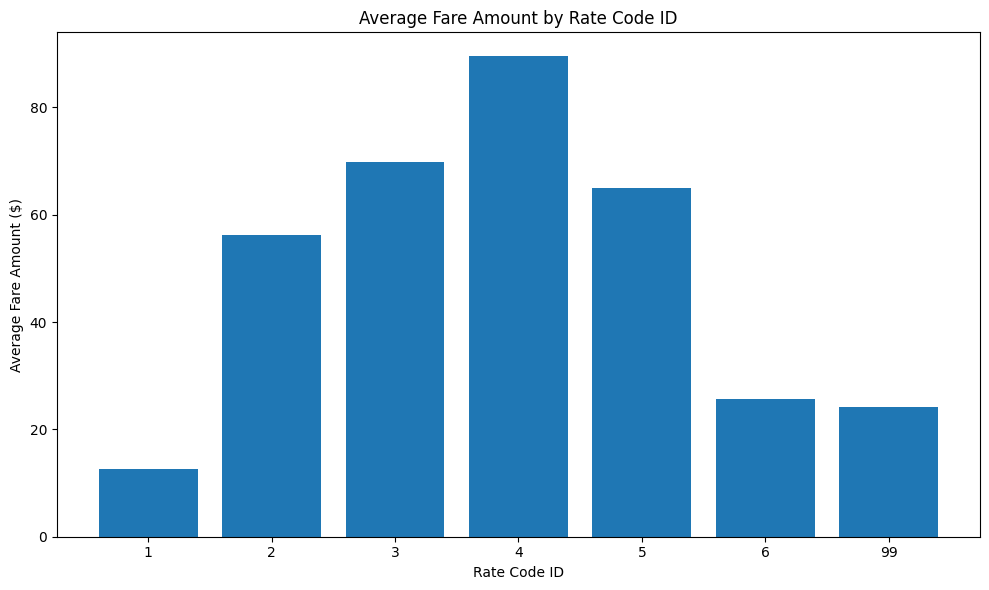

In [ ]:
import matplotlib.pyplot as plt
import os

plt.figure(figsize=(10, 6))

plt.bar(
    rate_fare_pd["ratecodeid"].astype(str),
    rate_fare_pd["avg_fare_amount"]
)

plt.xlabel("Rate Code ID")
plt.ylabel("Average Fare Amount ($)")
plt.title("Average Fare Amount by Rate Code ID")

plt.tight_layout()

plt.savefig(
    os.path.join(FIGURE_DIR, "rate_code_id_vs_average_fare.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
from pyspark.sql import functions as F

pickup_dropoff = (
    df
    .filter(
        F.col("pulocationid").isNotNull() &
        F.col("dolocationid").isNotNull()
    )
    .groupBy("pulocationid", "dolocationid")
    .agg(
        F.count("*").alias("trip_count")
    )
)
pickup_dropoff_pd = pickup_dropoff.toPandas()

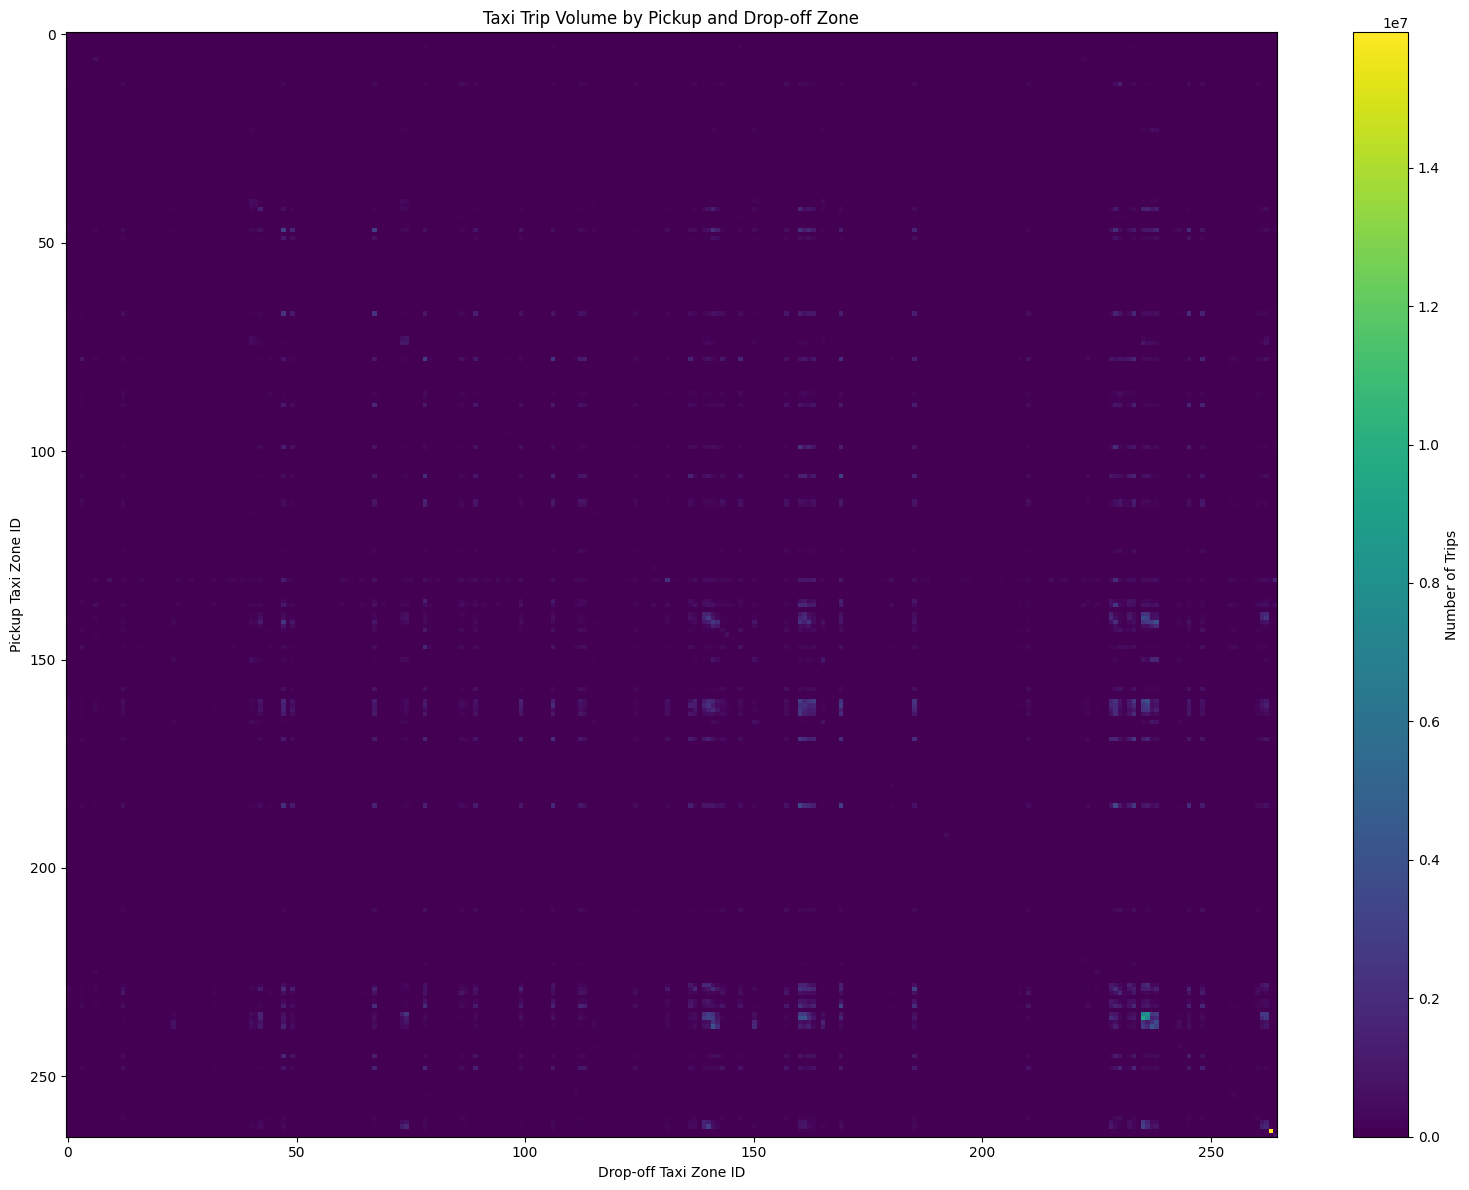

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import os

heatmap_data = pickup_dropoff_pd.pivot(
    index="pulocationid",
    columns="dolocationid",
    values="trip_count"
).fillna(0)

plt.figure(figsize=(16, 12))

plt.imshow(
    heatmap_data,
    aspect="auto",
    interpolation="nearest"
)

plt.colorbar(label="Number of Trips")

plt.xlabel("Drop-off Taxi Zone ID")
plt.ylabel("Pickup Taxi Zone ID")
plt.title("Taxi Trip Volume by Pickup and Drop-off Zone")

plt.tight_layout()

plt.savefig(
    os.path.join(FIGURE_DIR, "pickup_dropoff_taxi_zone_heatmap.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
from pyspark.sql import functions as F

speed_by_zone = (
    df
    .filter(
        (F.col("trip_distance") > 0) &
        (F.col("trip_distance") <= 100) &
        F.col("tpep_pickup_datetime").isNotNull() &
        F.col("tpep_dropoff_datetime").isNotNull()
    )
    .withColumn(
        "trip_duration_hours",
        (
            F.unix_timestamp("tpep_dropoff_datetime") -
            F.unix_timestamp("tpep_pickup_datetime")
        ) / 3600.0
    )
    .filter(
        (F.col("trip_duration_hours") > 0) &
        (F.col("trip_duration_hours") <= 3)
    )
    .withColumn(
        "speed_mph",
        F.col("trip_distance") / F.col("trip_duration_hours")
    )
)

In [ ]:
speed_by_zone = speed_by_zone.filter(
    F.col("speed_mph") <= 80
)

In [ ]:
avg_speed_by_zone = (
    speed_by_zone
    .groupBy("pulocationid")
    .agg(
        F.avg("speed_mph").alias("avg_speed_mph"),
        F.count("*").alias("trip_count")
    )
    .orderBy("pulocationid")
)

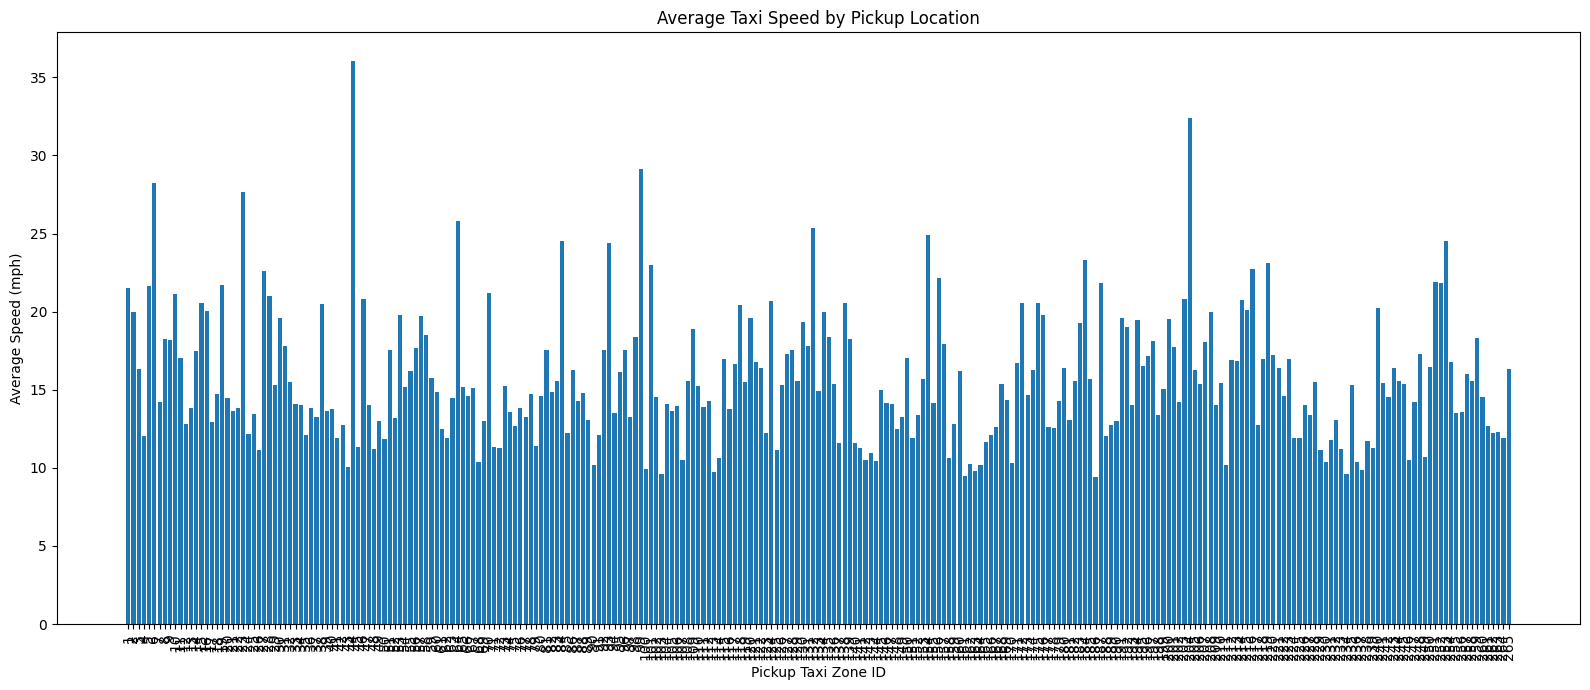

In [ ]:
speed_pd = avg_speed_by_zone.toPandas()

plt.figure(figsize=(16, 7))

plt.bar(
    speed_pd["pulocationid"].astype(str),
    speed_pd["avg_speed_mph"]
)

plt.xlabel("Pickup Taxi Zone ID")
plt.ylabel("Average Speed (mph)")
plt.title("Average Taxi Speed by Pickup Location")

plt.xticks(rotation=90)

plt.tight_layout()

plt.savefig(
    os.path.join(FIGURE_DIR, "average_speed_by_pickup_location.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()